In [1]:
import sys
import os
import torch
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Configuración de rutas
sys.path.append("..")
from models.ridge_model import RidgeModel
from models.random_forest_model import RandomForestModel
from models.xgboost_model import XGBoostModel
from models.lightgbm_model import LightGBMModel
from models.mlp_sklearn_model import MLPModel

print("Imports OK")

Imports OK


In [2]:
# ===============================
# 0. Configuración paths y device
# ===============================
os.makedirs('../outputs/plots', exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on: {device}")


Working on: cuda


In [4]:
# ===============================
# 1. Cargar embeddings y labels + SCORE ENERGÉTICO
# ===============================
print("Cargando datos y embeddings...")
df = pd.read_csv('../data/processed_dataset.csv')
embeddings = torch.load('../outputs/embeddings.pt')

Cargando datos y embeddings...


In [7]:
# Convertir embeddings a numpy (480 columnas)
X_emb = embeddings.numpy()

# EXTRAER SCORE ENERGÉTICO (La columna 'mpnn' del CSV)
# Asegúrate de que en tu CSV la columna se llame 'mpnn'
X_score = df['score'].values.reshape(-1, 1)

# CONCATENAR: 480 (ESM2) + 1 (MPNN) = 481 columnas
X = np.hstack([X_emb, X_score])

# Labels
y = df[['PTM', 'IPTM']].values

# Split de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Éxito: Matriz final con {X.shape[1]} columnas (480 ESM2 + 1 Score)")

✅ Éxito: Matriz final con 481 columnas (480 ESM2 + 1 Score)


In [8]:
# ===============================
# DISPLAY DE DISTRIBUCIÓN
# ===============================
print("-" * 30)
print(f"📊 Resumen del Split (80/20) con Feature Engineering:")
print(f"Total de registros: {len(X)}")
print(f"Columnas totales (Features): {X.shape[1]}") # Aquí debería decir 481
print(f"TRAIN (Entrenamiento): {X_train.shape[0]} muestras")
print(f"TEST  (Validación):    {X_test.shape[0]} muestras")
print("-" * 30)

------------------------------
📊 Resumen del Split (80/20) con Feature Engineering:
Total de registros: 45016
Columnas totales (Features): 481
TRAIN (Entrenamiento): 36012 muestras
TEST  (Validación):    9004 muestras
------------------------------


In [9]:
# ===============================
# 2. Configuración de Modelos
# ===============================
models_to_train = {
    "ridge": RidgeModel(),
    "rf": RandomForestModel(n_estimators=100),
    "xgb": XGBoostModel(n_estimators=500),
    "lgbm": LightGBMModel(),
    "mlp_sk": MLPModel(hidden_layer_sizes=(256, 128))
}

results = []

In [10]:
# ===============================
# 3. Loop de entrenamiento y evaluación
# ===============================
for name, model in models_to_train.items():
    print(f"Entrenando {name}...")
    model.fit(X_train, y_train)
    model.save(f"../outputs/model_{name}.pkl")
    
    preds = model.predict(X_test)
    
    # Métricas individuales
    r2_ptm = r2_score(y_test[:, 0], preds[:, 0])
    r2_iptm = r2_score(y_test[:, 1], preds[:, 1])
    rmse_ptm = np.sqrt(mean_squared_error(y_test[:, 0], preds[:, 0]))
    rmse_iptm = np.sqrt(mean_squared_error(y_test[:, 1], preds[:, 1]))
    
    results.append({
        "model": name,
        "R2_PTM": r2_ptm,
        "R2_IPTM": r2_iptm,
        "RMSE_PTM": rmse_ptm,
        "RMSE_IPTM": rmse_iptm
    })

df_results = pd.DataFrame(results)
df_results.to_csv('../outputs/model_metrics.csv', index=False)
display(df_results)

Entrenando ridge...

📈 Entrenando Ridge...
✅ Ridge terminado
⏱ Tiempo: 0.57 seg
💾 Modelo guardado: ../outputs/model_ridge.pkl
🔎 Prediciendo con Ridge...
Entrenando rf...

🌲 Entrenando Random Forest...
Samples: 36012
Features: 481


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=-1)]: Done  74 out of 100 | elapsed:   53.8s remaining:   18.9s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:   58.5s finished


✅ Entrenamiento terminado
⏱ Tiempo: 58.62 segundos
💾 Modelo guardado en: ../outputs/model_rf.pkl
🔎 Generando predicciones con Random Forest...
Entrenando xgb...

🚀 Entrenando XGBoost...


[Parallel(n_jobs=64)]: Using backend ThreadingBackend with 64 concurrent workers.
[Parallel(n_jobs=64)]: Done  74 out of 100 | elapsed:    0.1s remaining:    0.0s
[Parallel(n_jobs=64)]: Done 100 out of 100 | elapsed:    0.1s finished


✅ XGBoost terminado
⏱ Tiempo: 29.76 seg
💾 Modelo XGBoost guardado en: ../outputs/model_xgb.pkl
Entrenando lgbm...
Training LightGBM model...
LightGBM model saved to ../outputs/model_lgbm.pkl
Entrenando mlp_sk...

🧠 Entrenando MLP (Sklearn)...


/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Iteration 1, loss = 0.00586858
Iteration 2, loss = 0.00416028
Iteration 3, loss = 0.00401286
Iteration 4, loss = 0.00375128
Iteration 5, loss = 0.00365528
Iteration 6, loss = 0.00364855
Iteration 7, loss = 0.00345805
Iteration 8, loss = 0.00345484
Iteration 9, loss = 0.00328129
Iteration 10, loss = 0.00326970
Iteration 11, loss = 0.00324405
Iteration 12, loss = 0.00327274
Iteration 13, loss = 0.00328879
Iteration 14, loss = 0.00317738
Iteration 15, loss = 0.00313868
Iteration 16, loss = 0.00306603
Iteration 17, loss = 0.00316678
Iteration 18, loss = 0.00297592
Iteration 19, loss = 0.00303879
Iteration 20, loss = 0.00298056
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
✅ MLP terminado
⏱ Tiempo: 148.95 seg
💾 Modelo MLP guardado en: ../outputs/model_mlp_sk.pkl


,model,R2_PTM,R2_IPTM,RMSE_PTM,RMSE_IPTM
0,ridge,0.679027,0.759335,0.023360,0.111117
1,rf,0.833095,0.879600,0.016845,0.078593
2,xgb,0.843956,0.881668,0.016288,0.077916
3,lgbm,0.803814,0.853631,0.018263,0.086656
4,mlp_sk,0.263806,0.728038,0.035378,0.118121


In [11]:
# ===============================
# 4. Visualización de Resultados
# ===============================
def plot_analysis(y_true, y_pred, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # PTM
    sns.scatterplot(x=y_true[:, 0], y=y_pred[:, 0], ax=axes[0], alpha=0.3)
    axes[0].plot([0, 1], [0, 1], '--r')
    axes[0].set_title(f"{model_name} - PTM: Actual vs Pred")
    
    # IPTM
    sns.scatterplot(x=y_true[:, 1], y=y_pred[:, 1], ax=axes[1], alpha=0.3, color='orange')
    axes[1].plot([0, 1], [0, 1], '--r')
    axes[1].set_title(f"{model_name} - IPTM: Actual vs Pred")
    
    plt.tight_layout()
    plt.savefig(f"../outputs/plots/scatter_{model_name}.png")
    plt.show()

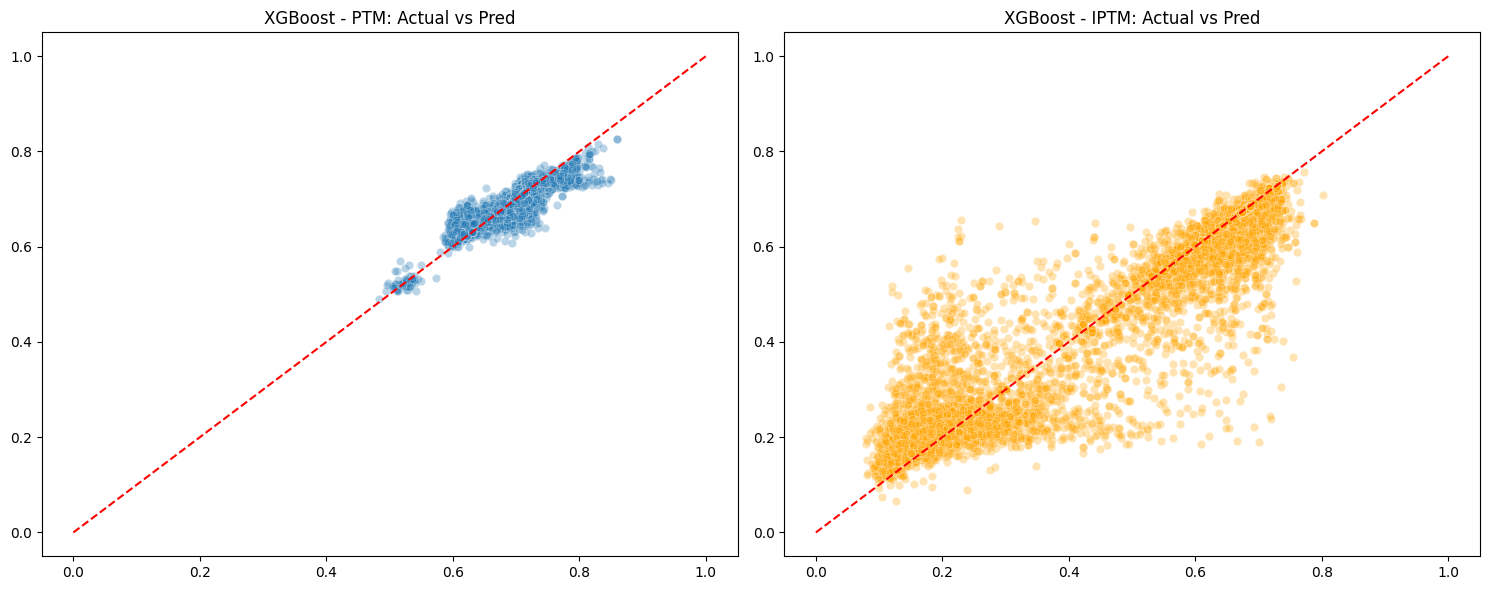

In [12]:
# Ejecutar para los dos mejores candidatos
best_preds_xgb = models_to_train['xgb'].predict(X_test)
plot_analysis(y_test, best_preds_xgb, "XGBoost")

/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/a01795976/miniconda3/envs/validador/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


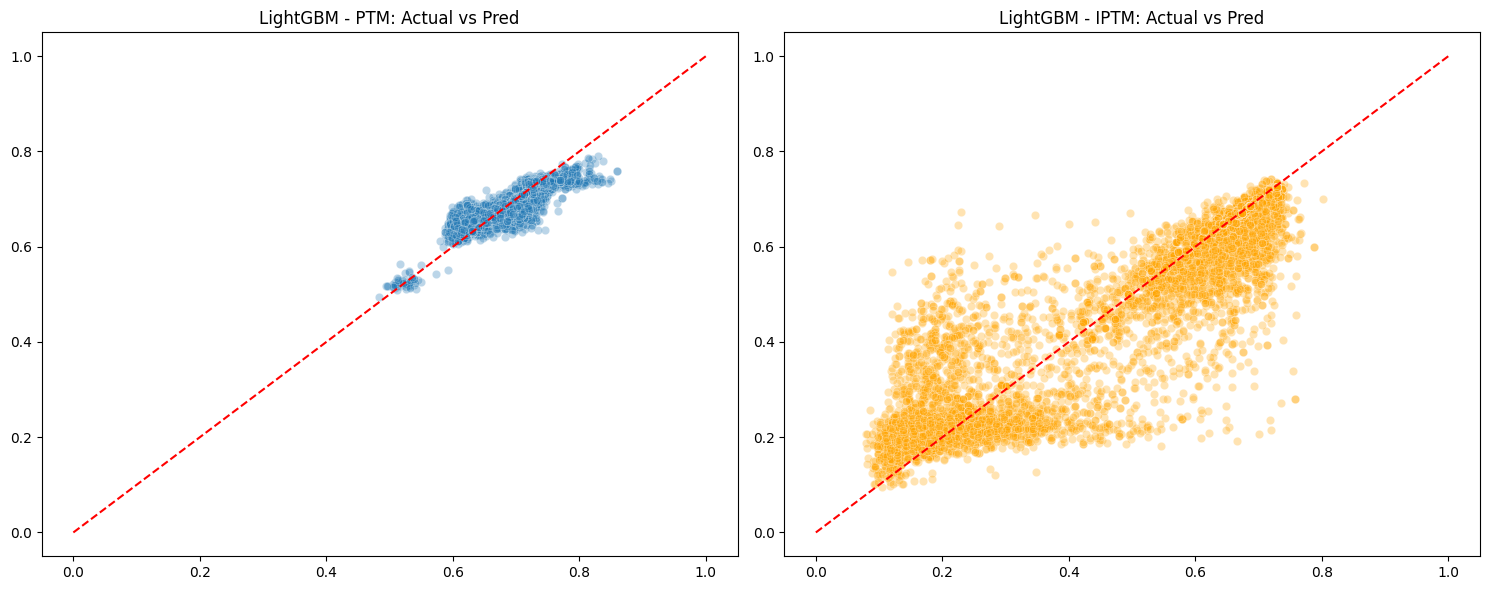

In [14]:
# Si LightGBM resulta ser mejor en tu dataset:
best_preds = models_to_train['lgbm'].predict(X_test)

# Quitamos df_results de aquí para que coincida con la definición de la función
plot_analysis(y_test, best_preds, "LightGBM")